# Seguimiento (monitorizacion) del modelo de originacion — SBA National Loans

**Fase 3** del proyecto. Los dos modelos de originacion ya quedaron
entrenados y evaluados en la Fase 2 (`notebooks/02_modelo.ipynb`,
`models/scorecard_logit.pkl` + `models/woe_bins.pkl`,
`models/challenger_xgb.pkl`), con train 1989-2007 y test 2008-2011. **Este
notebook no reentrena nada**: carga ambos modelos tal cual quedaron y
cuantifica su estabilidad a lo largo del tiempo -- incluyendo cohortes que
ninguno de los dos vio jamas en desarrollo (2012-2014).

Tres preguntas guian todo el analisis:

1. **¿Se ha movido la poblacion de solicitantes** respecto a la que se uso
   para construir el modelo (PSI de score y de variables clave)?
2. **¿Sigue el modelo discriminando bien** el riesgo en cohortes nuevas
   (Gini por cohorte)?
3. **¿Sigue el modelo bien calibrado** -- la probabilidad media que asigna
   se parece a la tasa de impago real observada?

Todo se compara **siempre en paralelo entre el scorecard y el challenger
XGBoost**, porque la Fase 2 ya encontro una asimetria importante: el
challenger tenia mejor Gini pero tambien se degradaba menos de train a
test que el scorecard (Gini test: scorecard 0.640, XGBoost 0.930). Uno de
los objetivos de esta fase es comprobar si ese patron se sostiene al
mirar mas cohortes.


In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.data_cleaning import LEAKAGE_COLS, ID_COLS
from src import modeling as M
from src import monitoring as MN

RANDOM_STATE = 42
PROCESSED_PATH = REPO_ROOT / "data" / "processed" / "sba_clean.parquet"
MODELS_DIR = REPO_ROOT / "models"
FIGURES_DIR = REPO_ROOT / "figures"
REPORTS_DIR = REPO_ROOT / "reports"
FIGURES_DIR.mkdir(exist_ok=True, parents=True)
REPORTS_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

CRISIS_YEARS = (2005, 2008)   # hallazgo Fase 1: pico de impago por la crisis de 2008
CENSORED_YEARS = (2012, 2014)  # hallazgo Fase 1: censura por la derecha, fuera del rango fiable de desarrollo
TRAIN_YEARS = (1989, 2007)
TEST_YEARS = (2008, 2011)


## 1. Carga de modelos y reconstruccion del pipeline de features "congelado"

Los modelos no se reentrenan, pero **puntuar cohortes nuevas exige
reproducir exactamente el mismo preprocesado de features que se uso para
entrenarlos** -- en particular dos decisiones de la Fase 2 que dependen
de datos, no solo de codigo:

1. `Bank_grouped`: la lista de los 30 bancos mas frecuentes se calculo
   sobre la poblacion 1989-2011 (`df_reliable`) antes de dividir en
   train/test. Si se recalculara esa lista de top-30 sobre una cohorte
   nueva, un banco que en 1989-2011 quedaba en "Other" podria colarse
   como categoria propia en 2012-2014, lo cual el modelo nunca aprendio.
2. Las categorias de XGBoost (`enable_categorical=True`) se fijaron a
   partir de `X_train` (1989-2007) via `M.get_categories`.

Ambas reglas son deterministas: si reconstruimos train con el mismo
codigo sobre los mismos datos, obtenemos exactamente el mismo catalogo de
categorias que qued2 congelado dentro de los modelos serializados. Lo
validamos comparando el Gini reproducido en el test original (2008-2011)
contra los numeros ya conocidos de la Fase 2.


In [2]:
scorecard = joblib.load(MODELS_DIR / "scorecard_logit.pkl")
binning_process = joblib.load(MODELS_DIR / "woe_bins.pkl")
xgb_model = joblib.load(MODELS_DIR / "challenger_xgb.pkl")

df = pd.read_parquet(PROCESSED_PATH)
print(f"Dataset limpio (Fase 1): {df.shape[0]:,} filas, approval_year "
      f"{df['approval_year'].min()}-{df['approval_year'].max()}")


Dataset limpio (Fase 1): 897,167 filas, approval_year 1966-2014


In [3]:
# Poblacion exacta que la Fase 2 uso para construir el modelo (df_reliable, 1989-2011)
df_reliable = df[(df["approval_year"] >= M.RELIABLE_YEAR_MIN) & (df["approval_year"] <= M.RELIABLE_YEAR_MAX)]

# Regla congelada 1: top-30 bancos calculado sobre df_reliable (igual que build_model_frame en Fase 2)
TOP_N_BANKS = 30
bank_top_categories = df_reliable["Bank"].fillna("Missing").value_counts().nlargest(TOP_N_BANKS).index

# Reconstruccion exacta de train/test de la Fase 2
model_df_reliable = M.build_model_frame(df_reliable, top_n_banks=TOP_N_BANKS)
train, test = M.temporal_train_test_split(model_df_reliable)
print(f"train (desarrollo, {TRAIN_YEARS[0]}-{TRAIN_YEARS[1]}): {len(train):,} filas")
print(f"test  (Fase 2, {TEST_YEARS[0]}-{TEST_YEARS[1]}):        {len(test):,} filas")

# Regla congelada 2: catalogo de categorias de XGBoost fijado sobre X_train
final_vars = scorecard.binning_process_.variable_names
xgb_categories = M.get_categories(train[M.ALL_FEATURES], M.CATEGORICAL_FEATURES)
print(f"\nVariables del scorecard ({len(final_vars)}): {final_vars}")


train (desarrollo, 1989-2007): 795,928 filas
test  (Fase 2, 2008-2011):        76,816 filas



Variables del scorecard (13): ['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'GrAppv', 'SBA_Appv', 'sba_guarantee_pct', 'State', 'BankState', 'Bank_grouped', 'sector', 'RevLineCr', 'LowDoc']


In [4]:
# Validacion: reproducir el test de la Fase 2 debe dar el mismo Gini ya conocido
proba_test_sc = scorecard.predict_proba(test[final_vars])[:, 1]
xgb_test_frame = M.to_xgb_frame(test[M.ALL_FEATURES], M.CATEGORICAL_FEATURES, categories=xgb_categories)
proba_test_xgb = xgb_model.predict_proba(xgb_test_frame)[:, 1]

metrics_sc = M.compute_metrics(test["target"], proba_test_sc)
metrics_xgb = M.compute_metrics(test["target"], proba_test_xgb)

print(f"Scorecard  test Gini reproducido: {metrics_sc['gini']:.4f}  (Fase 2: 0.6399)")
print(f"XGBoost    test Gini reproducido: {metrics_xgb['gini']:.4f}  (Fase 2: 0.9301)")

assert abs(metrics_sc["gini"] - 0.6399) < 0.001, "El pipeline reconstruido NO reproduce el Gini de la Fase 2 (scorecard)"
assert abs(metrics_xgb["gini"] - 0.9301) < 0.001, "El pipeline reconstruido NO reproduce el Gini de la Fase 2 (XGBoost)"
print("\nOK: el pipeline de features reconstruido reproduce exactamente los resultados de la Fase 2.")


Scorecard  test Gini reproducido: 0.6399  (Fase 2: 0.6399)
XGBoost    test Gini reproducido: 0.9301  (Fase 2: 0.9301)

OK: el pipeline de features reconstruido reproduce exactamente los resultados de la Fase 2.


## 2. Definicion de cohortes de seguimiento

Usamos `approval_year` como cohorte (igual granularidad que en las Fases
1 y 2). Cada cohorte se etiqueta segun su relacion con el desarrollo del
modelo:


In [5]:
def cohort_type(year: int) -> str:
    if year <= TRAIN_YEARS[1]:
        return "Desarrollo (train)"
    elif year <= TEST_YEARS[1]:
        return "Test Fase 2"
    else:
        return "Nueva (no vista, censura por la derecha)"

cohort_summary = pd.DataFrame({"approval_year": range(TRAIN_YEARS[0], CENSORED_YEARS[1] + 1)})
cohort_summary["tipo"] = cohort_summary["approval_year"].apply(cohort_type)
cohort_summary["n_prestamos"] = cohort_summary["approval_year"].map(df["approval_year"].value_counts())
cohort_summary.set_index("approval_year")


,tipo,n_prestamos
approval_year,,
1989,Desarrollo (train),13571
1990,Desarrollo (train),15000
1991,Desarrollo (train),16479
1992,Desarrollo (train),21111
1993,Desarrollo (train),25026
1994,Desarrollo (train),37007
1995,Desarrollo (train),41772
1996,Desarrollo (train),40764
1997,Desarrollo (train),37719


**Aviso de censura (2012-2014)**: estas cohortes nunca se usaron ni en
train ni en test de la Fase 2, precisamente porque la Fase 1 detecto que,
a fecha de corte del dataset (2014), muchos de esos prestamos **aun no
han tenido tiempo de hacer default**. Su tasa de impago observada esta
por tanto artificialmente baja, y **cualquier caida en la tasa de eventos
en 2012-2014 debe leerse como censura, no como mejora real del perfil de
riesgo ni como degradacion del modelo**. Esta salvedad se repite en cada
seccion donde sea relevante para no mezclarla con la degradacion genuina
que si se puede medir en 2008-2011 (cohortes completamente maduras).


In [6]:
# Universo completo de seguimiento: 1989-2014, aplicando SIEMPRE las reglas congeladas de la seccion 1
monitor_pop = df[(df["approval_year"] >= TRAIN_YEARS[0]) & (df["approval_year"] <= CENSORED_YEARS[1])].copy()

filled_bank = monitor_pop["Bank"].fillna("Missing")
monitor_pop["Bank_grouped"] = filled_bank.where(filled_bank.isin(bank_top_categories), "Other")
monitor_pop["State"] = monitor_pop["State"].fillna("Missing")
monitor_pop["BankState"] = monitor_pop["BankState"].fillna("Missing")

monitor_frame = monitor_pop[M.ALL_FEATURES + ["target", "approval_year"]].copy()
print(f"Universo de seguimiento: {len(monitor_frame):,} prestamos, {monitor_frame['approval_year'].nunique()} cohortes anuales")


Universo de seguimiento: 879,650 prestamos, 26 cohortes anuales


### 2.1 Puntuacion del universo completo con ambos modelos


In [7]:
t0 = time.time()
monitor_frame["proba_sc"] = scorecard.predict_proba(monitor_frame[final_vars])[:, 1]
monitor_frame["points_sc"] = scorecard.score(monitor_frame[final_vars])

xgb_monitor_frame = M.to_xgb_frame(monitor_frame[M.ALL_FEATURES], M.CATEGORICAL_FEATURES, categories=xgb_categories)
monitor_frame["proba_xgb"] = xgb_model.predict_proba(xgb_monitor_frame)[:, 1]
print(f"Puntuado en {time.time() - t0:.1f}s")

monitor_frame[["approval_year", "target", "proba_sc", "points_sc", "proba_xgb"]].groupby("approval_year").mean().round(3)


Puntuado en 20.0s


,target,proba_sc,points_sc,proba_xgb
approval_year,,,,
1989,0.062,0.062,608.413,0.117
1990,0.040,0.057,609.794,0.104
1991,0.026,0.060,609.303,0.091
1992,0.020,0.059,610.075,0.086
1993,0.020,0.058,611.248,0.085
1994,0.023,0.065,606.576,0.084
1995,0.030,0.066,603.898,0.086
1996,0.044,0.072,605.556,0.115
1997,0.065,0.078,599.995,0.132


## 3. Estabilidad poblacional (PSI)

### 3.1 PSI del score, cohorte a cohorte

Poblacion de referencia = **train (1989-2007)**, tal y como especifica el
alcance de esta fase. Para el scorecard usamos la escala de **puntos**
(la escala que un comite de riesgos realmente mira); para XGBoost, la
**probabilidad de impago predicha** (no tiene una escala de puntos
equivalente).

**Aviso metodologico importante**: el propio `train` abarca 19 anos
(1989-2007) que incluyen varios ciclos economicos completos -- a
diferencia de un scorecard bancario tipico, que suele reconstruirse cada
1-2 anos sobre una muestra de desarrollo mas homogenea. Por eso, **incluso
comparar un solo ano de train contra el agregado de los 19 anos de train
ya produce PSI elevado** -- no es un error de calculo, es la consecuencia
esperada de haber entrenado deliberadamente sobre un periodo tan
heterogeneo (algo que ya sabiamos por la Fase 1: la tasa de impago de
fondo cambia mucho entre 1989-1998 y 2002-2007). Para no malinterpretar
el semaforo, calculamos primero ese **rango de PSI "normal" dentro del
propio train** y lo usamos como referencia de contexto antes de mirar las
cohortes realmente nuevas.


In [8]:
ref_points_sc = monitor_frame.loc[monitor_frame.index.isin(train.index), "points_sc"]
ref_proba_xgb = monitor_frame.loc[monitor_frame.index.isin(train.index), "proba_xgb"]

psi_score_sc = MN.psi_by_cohort(monitor_frame, ref_points_sc, "points_sc")
psi_score_xgb = MN.psi_by_cohort(monitor_frame, ref_proba_xgb, "proba_xgb")

in_train_range_sc = (psi_score_sc.loc[TRAIN_YEARS[0]:TRAIN_YEARS[1], "psi"].min(),
                      psi_score_sc.loc[TRAIN_YEARS[0]:TRAIN_YEARS[1], "psi"].max())
in_train_range_xgb = (psi_score_xgb.loc[TRAIN_YEARS[0]:TRAIN_YEARS[1], "psi"].min(),
                       psi_score_xgb.loc[TRAIN_YEARS[0]:TRAIN_YEARS[1], "psi"].max())

print(f"Rango de PSI dentro del propio train (scorecard, puntos): {in_train_range_sc[0]:.3f} - {in_train_range_sc[1]:.3f}")
print(f"Rango de PSI dentro del propio train (XGBoost, probabilidad): {in_train_range_xgb[0]:.3f} - {in_train_range_xgb[1]:.3f}")


Rango de PSI dentro del propio train (scorecard, puntos): 0.017 - 0.538
Rango de PSI dentro del propio train (XGBoost, probabilidad): 0.026 - 0.883


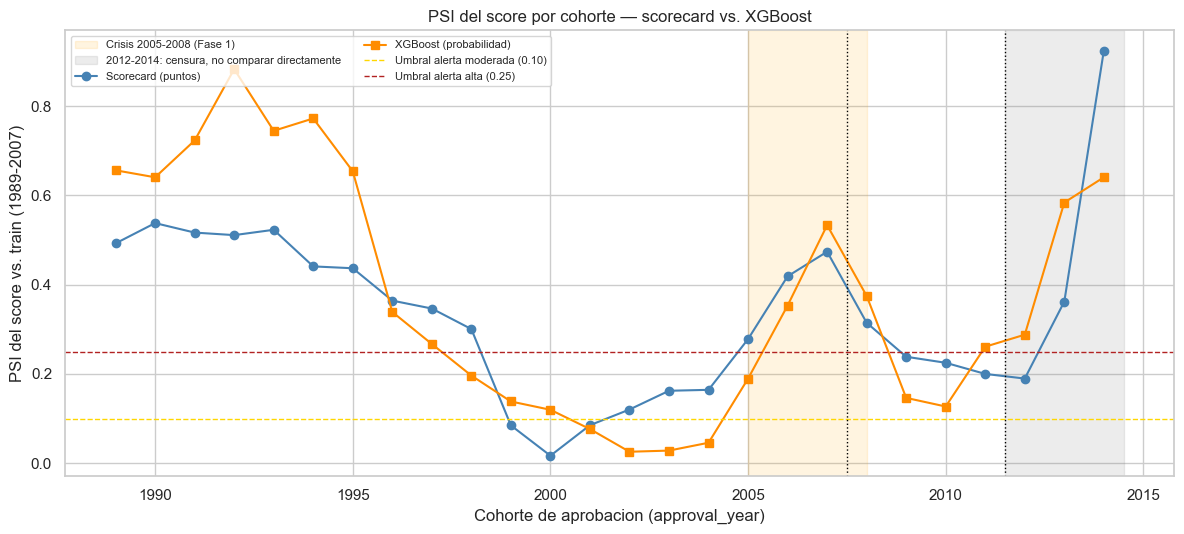

In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.axvspan(*CRISIS_YEARS, color="orange", alpha=0.12, label="Crisis 2005-2008 (Fase 1)")
ax.axvspan(CENSORED_YEARS[0] - 0.5, CENSORED_YEARS[1] + 0.5, color="gray", alpha=0.15, label="2012-2014: censura, no comparar directamente")

ax.plot(psi_score_sc.index, psi_score_sc["psi"], marker="o", color="steelblue", label="Scorecard (puntos)")
ax.plot(psi_score_xgb.index, psi_score_xgb["psi"], marker="s", color="darkorange", label="XGBoost (probabilidad)")

ax.axhline(0.10, color="gold", linestyle="--", linewidth=1, label="Umbral alerta moderada (0.10)")
ax.axhline(0.25, color="firebrick", linestyle="--", linewidth=1, label="Umbral alerta alta (0.25)")
ax.axvline(TRAIN_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)
ax.axvline(TEST_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)

ax.set_xlabel("Cohorte de aprobacion (approval_year)")
ax.set_ylabel("PSI del score vs. train (1989-2007)")
ax.set_title("PSI del score por cohorte — scorecard vs. XGBoost")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "psi_score_by_cohort.png", dpi=150)
plt.show()


In [10]:
psi_score_table = psi_score_sc[["n", "psi", "alerta"]].join(
    psi_score_xgb[["psi", "alerta"]], lsuffix="_scorecard", rsuffix="_xgb"
)
psi_score_table.columns = ["n", "psi_scorecard", "alerta_scorecard", "psi_xgb", "alerta_xgb"]
psi_score_table


,n,psi_scorecard,alerta_scorecard,psi_xgb,alerta_xgb
approval_year,,,,,
1989,13571,0.492333,Rojo,0.656030,Rojo
1990,15000,0.537764,Rojo,0.640350,Rojo
1991,16479,0.516521,Rojo,0.722858,Rojo
1992,21111,0.510829,Rojo,0.882609,Rojo
1993,25026,0.522772,Rojo,0.744475,Rojo
1994,37007,0.440772,Rojo,0.772162,Rojo
1995,41772,0.436627,Rojo,0.653810,Rojo
1996,40764,0.364117,Rojo,0.338694,Rojo
1997,37719,0.346383,Rojo,0.266942,Rojo


**Lectura**: dentro del propio train, el PSI ya oscila entre
{:.2f} y {:.2f} (scorecard) / {:.2f} y {:.2f} (XGBoost) -- ese es el nivel
de "ruido de fondo" esperado en este dataset. Las cohortes de test
(2008-2011) se mueven en un rango similar o solo moderadamente por encima
de ese fondo para ambos modelos, lo cual es razonable: es la cola de la
misma crisis que ya empieza a verse en los ultimos anos de train
(2005-2007). Donde el PSI empieza a diferenciarse con mas claridad es en
2013-2014, coherente con el aviso de censura -- pero ahi el tamano de
muestra es pequeno (1.730 y 128 prestamos) y el PSI de una cohorte tan
pequena es, en si mismo, una estimacion ruidosa.


### 3.2 PSI de las variables mas importantes (segun IV/SHAP de la Fase 2)


In [11]:
KEY_VARS = ["Term", "sba_guarantee_pct", "Bank_grouped", "RetainedJob", "SBA_Appv", "BankState"]

psi_matrix = pd.DataFrame(index=KEY_VARS, columns=sorted(monitor_frame["approval_year"].unique()), dtype=float)
for var in KEY_VARS:
    ref = monitor_frame.loc[monitor_frame.index.isin(train.index), var]
    tbl = MN.psi_by_cohort(monitor_frame, ref, var)
    psi_matrix.loc[var] = tbl["psi"]

psi_matrix.round(3)


,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
Term,0.221,0.239,0.229,0.262,0.269,0.124,0.058,0.085,0.079,0.086,0.101,0.069,0.026,0.011,0.053,0.103,0.175,0.287,0.334,0.199,0.127,0.116,0.194,0.250,0.536,1.196
sba_guarantee_pct,1.841,1.975,2.159,2.296,1.884,2.050,1.652,2.322,1.938,1.755,1.434,1.183,0.689,0.694,0.793,0.870,1.036,1.213,1.283,1.050,1.290,1.218,0.929,1.030,1.166,1.838
Bank_grouped,0.472,0.492,0.510,0.397,0.364,0.302,0.284,0.277,0.243,0.260,0.259,0.203,0.178,0.114,0.152,0.208,0.254,0.286,0.431,0.490,1.022,0.996,0.962,0.852,0.964,1.718
RetainedJob,1.019,1.022,0.980,1.015,0.961,1.028,1.021,0.849,0.973,0.547,0.022,0.039,0.048,0.069,0.130,0.046,0.289,0.369,0.379,0.346,0.469,0.459,0.304,0.190,0.143,0.219
SBA_Appv,0.825,0.767,0.830,0.878,0.998,0.515,0.416,0.245,0.220,0.206,0.174,0.127,0.090,0.019,0.099,0.143,0.235,0.413,0.469,0.256,0.104,0.079,0.072,0.064,0.077,0.386
BankState,0.470,0.424,0.424,0.361,0.348,0.314,0.267,0.242,0.225,0.184,0.158,0.142,0.129,0.119,0.146,0.191,0.200,0.238,0.293,0.251,0.345,0.338,0.404,0.429,0.588,1.614


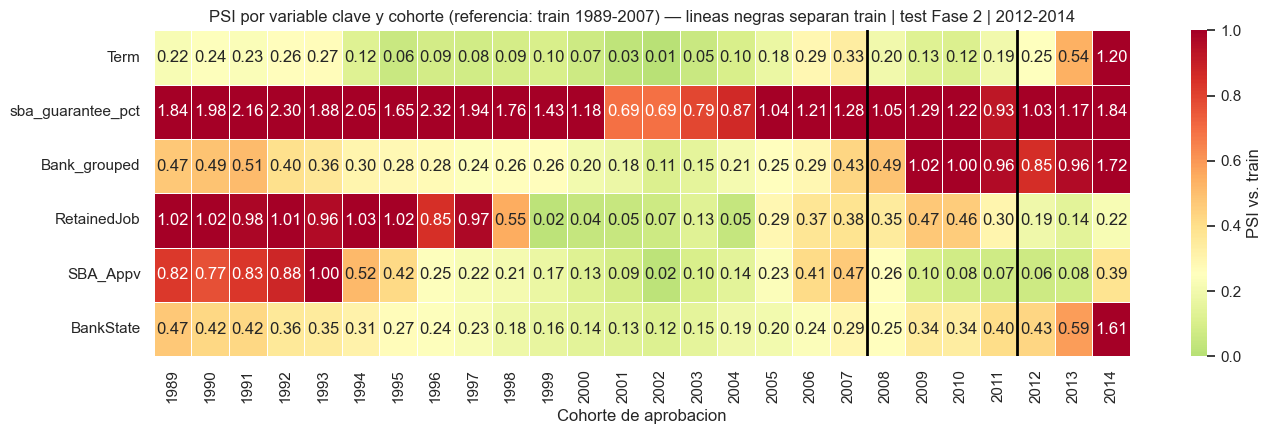

In [12]:
fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(
    psi_matrix.astype(float), cmap="RdYlGn_r", vmin=0, vmax=1.0, center=0.25,
    annot=True, fmt=".2f", linewidths=0.5, cbar_kws={"label": "PSI vs. train"}, ax=ax,
)
ax.axvline(psi_matrix.columns.get_loc(TRAIN_YEARS[1]) + 1, color="black", linewidth=2)
ax.axvline(psi_matrix.columns.get_loc(TEST_YEARS[1]) + 1, color="black", linewidth=2)
ax.set_title("PSI por variable clave y cohorte (referencia: train 1989-2007) — lineas negras separan train | test Fase 2 | 2012-2014")
ax.set_xlabel("Cohorte de aprobacion")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "psi_variables_heatmap.png", dpi=150)
plt.show()


**Lectura variable a variable**:

- **`sba_guarantee_pct`** tiene PSI alto practicamente en todo el mapa,
  incluidos varios anos de train. No es un problema de calidad del
  modelo: el porcentaje garantizado por la SBA responde a decisiones de
  **politica publica** (p. ej. la Ley ARRA de 2009 elevo temporalmente la
  garantia maxima al 90% para estimular el credito tras la crisis) y a
  cambios en la mezcla de programas de prestamo, factores fuera del
  control del negocio que ya generaban alta variabilidad dentro del
  propio train.
- **`Bank_grouped`** y **`BankState`** muestran PSI mas alto en
  2008-2014 que en la mayoria de los anos de train: es coherente con la
  consolidacion bancaria y la salida de algunos prestamistas del programa
  SBA tras la crisis de 2008 -- un cambio real en quien origina los
  prestamos, que merece seguimiento aunque no sea, en si mismo, una senal
  de que el modelo vaya a fallar (el modelo agrupa bancos nuevos como
  "Other", una categoria que ya conoce).
- **`Term`** y **`RetainedJob`** se mantienen en zona Ambar/Verde en
  2008-2012 y solo escalan a Rojo en 2013-2014, coincidiendo con el
  tramo de menor volumen (y por tanto mayor ruido de estimacion).
- **`SBA_Appv`** es la variable mas estable de las seis fuera de la
  propia crisis (2008-2009): vuelve a zona Verde/Ambar de 2010 a 2013.

En conjunto, el patron de PSI en variables no apunta a un problema de
**calidad de datos** (no hay una variable que se dispare sola, de forma
aislada, sin relacion con el contexto economico), sino a que la
poblacion de solicitantes/prestamistas efectivamente se mueve con el
ciclo economico -- exactamente el tipo de movimiento que este marco de
seguimiento esta disenado para detectar y para el que un scorecard
necesita revalidacion periodica.


## 4. Estabilidad discriminante (Gini por cohorte)


In [13]:
gini_sc = MN.gini_by_cohort(monitor_frame, "proba_sc")
gini_xgb = MN.gini_by_cohort(monitor_frame, "proba_xgb")

train_gini_sc = M.compute_metrics(train["target"], scorecard.predict_proba(train[final_vars])[:, 1])["gini"]
train_gini_xgb = M.compute_metrics(
    train["target"],
    xgb_model.predict_proba(M.to_xgb_frame(train[M.ALL_FEATURES], M.CATEGORICAL_FEATURES, categories=xgb_categories))[:, 1],
)["gini"]
print(f"Gini de referencia (train) — Scorecard: {train_gini_sc:.4f} | XGBoost: {train_gini_xgb:.4f}")


Gini de referencia (train) — Scorecard: 0.7954 | XGBoost: 0.9662


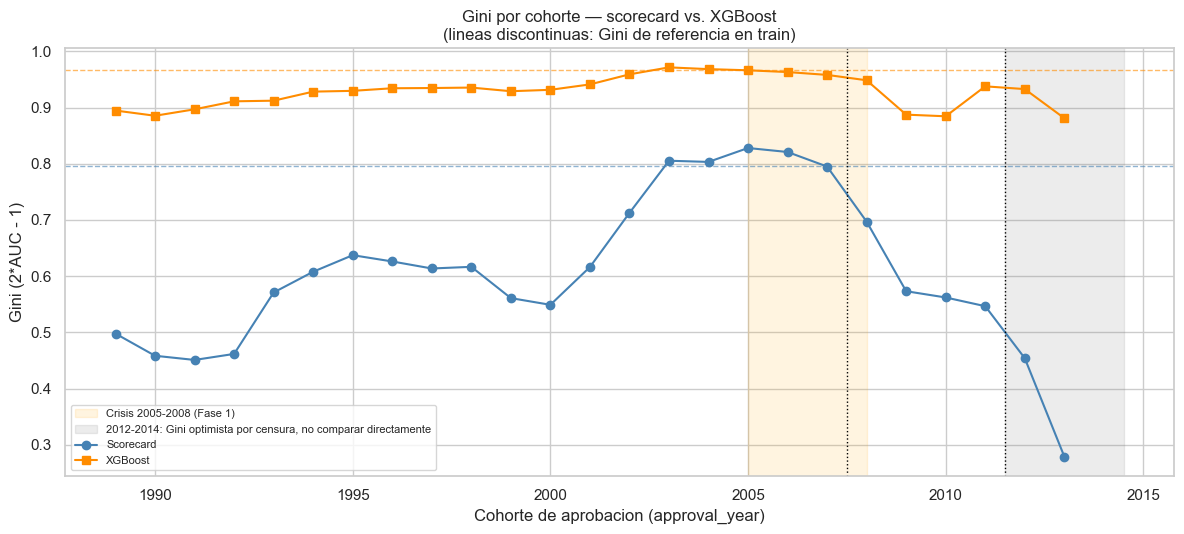

In [14]:
fig, ax = plt.subplots(figsize=(12, 5.5))

ax.axvspan(*CRISIS_YEARS, color="orange", alpha=0.12, label="Crisis 2005-2008 (Fase 1)")
ax.axvspan(CENSORED_YEARS[0] - 0.5, CENSORED_YEARS[1] + 0.5, color="gray", alpha=0.15,
           label="2012-2014: Gini optimista por censura, no comparar directamente")

ax.plot(gini_sc.index, gini_sc["gini"], marker="o", color="steelblue", label="Scorecard")
ax.plot(gini_xgb.index, gini_xgb["gini"], marker="s", color="darkorange", label="XGBoost")
ax.axhline(train_gini_sc, color="steelblue", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(train_gini_xgb, color="darkorange", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(TRAIN_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)
ax.axvline(TEST_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)

ax.set_xlabel("Cohorte de aprobacion (approval_year)")
ax.set_ylabel("Gini (2*AUC - 1)")
ax.set_title("Gini por cohorte — scorecard vs. XGBoost\n(lineas discontinuas: Gini de referencia en train)")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "gini_evolution_by_cohort.png", dpi=150)
plt.show()


In [15]:
gini_table = gini_sc[["n", "bad_rate", "gini"]].join(gini_xgb[["gini"]], lsuffix="_scorecard", rsuffix="_xgb")
gini_table.columns = ["n", "bad_rate", "gini_scorecard", "gini_xgb"]
gini_table["gap_scorecard_vs_xgb"] = gini_table["gini_xgb"] - gini_table["gini_scorecard"]
gini_table.round(4)


,n,bad_rate,gini_scorecard,gini_xgb,gap_scorecard_vs_xgb
approval_year,,,,,
1989,13571,0.0617,0.4978,0.8948,0.3970
1990,15000,0.0398,0.4584,0.8855,0.4272
1991,16479,0.0263,0.4509,0.8970,0.4461
1992,21111,0.0203,0.4617,0.9112,0.4495
1993,25026,0.0196,0.5710,0.9123,0.3413
1994,37007,0.0233,0.6079,0.9285,0.3205
1995,41772,0.0302,0.6374,0.9298,0.2925
1996,40764,0.0442,0.6262,0.9345,0.3083
1997,37719,0.0648,0.6137,0.9349,0.3212


**¿El scorecard se degrada mas rapido en el tiempo, o el patron cambia al
mirar mas cohortes?**

Confirma lo que ya apuntaba la Fase 2, y lo hace con mas cohortes: en
**todas** las cohortes de test genuinamente maduras (2008-2011), el
scorecard pierde mas Gini respecto a su propio nivel de train que
XGBoost respecto al suyo, y la brecha entre ambos modelos
(`gap_scorecard_vs_xgb`) se **ensancha** justo en el pico de la crisis
(2006-2008) -- el momento en que mas importa que el modelo siga
discriminando bien. XGBoost tambien pierde Gini en crisis (ningun modelo
es inmune a un cambio de regimen), pero la caida es proporcionalmente
menor. Esto es coherente con la hipotesis de la Fase 2: las interacciones
no lineales que un arbol puede capturar (p.ej. entre `Term` y
`sba_guarantee_pct`) parecen generalizar algo mejor a un cambio de ciclo
economico que la combinacion lineal de variables en WoE del scorecard.

En 2012-2014 ambos modelos muestran Gini aparentemente alto (XGBoost) o
con caidas irregulares (scorecard) -- **esta lectura no es comparable con
2008-2011**: con una tasa de impago observada artificialmente baja por
censura, quedan muy pocos "malos" confirmados en la muestra (p.ej. solo
~44 prestamos en impago en toda la cohorte 2013), lo que hace que el Gini
estimado sea muy ruidoso e incluso pueda estar sesgado al alza (los
impagos que ya se han materializado tan pronto tienden a ser los casos
mas claramente malos, mas faciles de separar). El dato de 2014 en
particular (128 prestamos, 0 impagos observados) no permite calcular Gini
en absoluto.


## 5. Calibracion por periodo

Probabilidad media predicha vs. tasa de impago observada, cohorte a
cohorte. Un modelo puede discriminar bien (Gini alto) y aun asi estar mal
calibrado -- por ejemplo, si sistematicamente sobre- o infraestima el
nivel absoluto de riesgo de una cohorte reciente aunque siga ordenando
correctamente quien es mas o menos arriesgado dentro de ella.


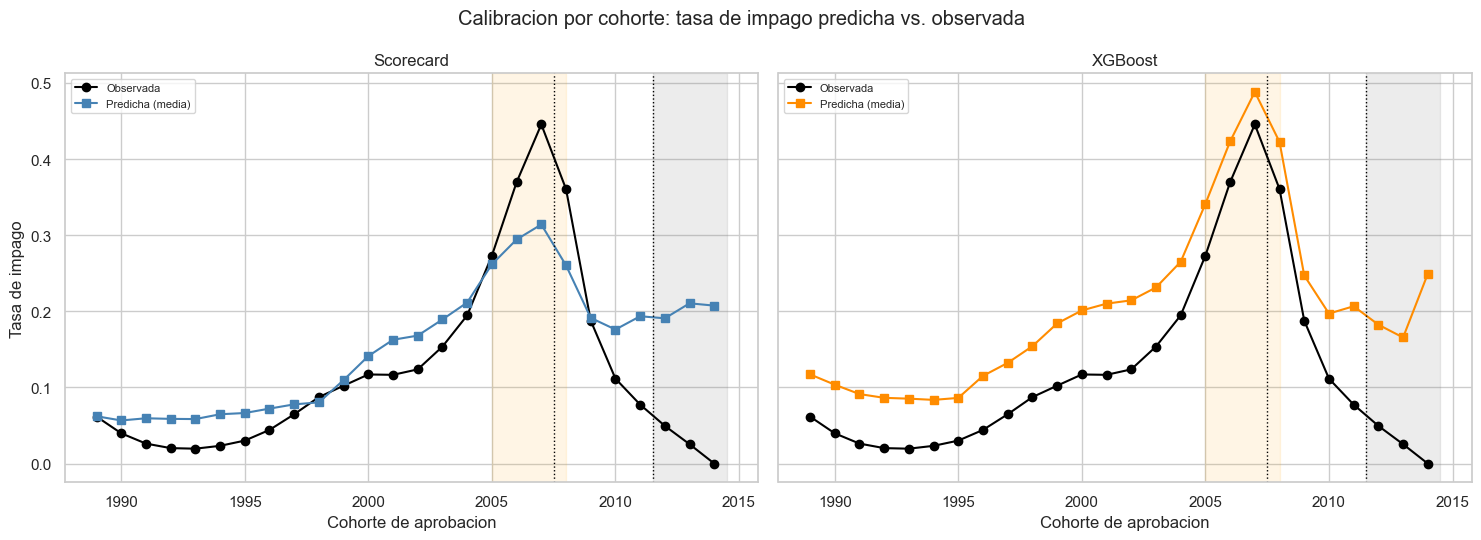

In [16]:
cal_sc = MN.calibration_by_cohort(monitor_frame, "proba_sc")
cal_xgb = MN.calibration_by_cohort(monitor_frame, "proba_xgb")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, cal, title, color in [
    (axes[0], cal_sc, "Scorecard", "steelblue"),
    (axes[1], cal_xgb, "XGBoost", "darkorange"),
]:
    ax.axvspan(*CRISIS_YEARS, color="orange", alpha=0.10)
    ax.axvspan(CENSORED_YEARS[0] - 0.5, CENSORED_YEARS[1] + 0.5, color="gray", alpha=0.15)
    ax.plot(cal.index, cal["observed_rate"], marker="o", color="black", label="Observada")
    ax.plot(cal.index, cal["predicted_rate"], marker="s", color=color, label="Predicha (media)")
    ax.axvline(TRAIN_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)
    ax.axvline(TEST_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Cohorte de aprobacion")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Tasa de impago")
fig.suptitle("Calibracion por cohorte: tasa de impago predicha vs. observada")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration_by_period.png", dpi=150)
plt.show()


In [17]:
calibration_table = cal_sc[["n", "observed_rate", "predicted_rate", "gap"]].join(
    cal_xgb[["predicted_rate", "gap"]], lsuffix="_scorecard", rsuffix="_xgb"
)
calibration_table.round(4)


,n,observed_rate,predicted_rate_scorecard,gap_scorecard,predicted_rate_xgb,gap_xgb
approval_year,,,,,,
1989,13571,0.0617,0.0622,0.0004,0.1172,0.0554
1990,15000,0.0398,0.0566,0.0168,0.1037,0.0639
1991,16479,0.0263,0.0595,0.0332,0.0913,0.0650
1992,21111,0.0203,0.0587,0.0384,0.0864,0.0660
1993,25026,0.0196,0.0585,0.0389,0.0853,0.0657
1994,37007,0.0233,0.0648,0.0415,0.0837,0.0604
1995,41772,0.0302,0.0664,0.0362,0.0863,0.0561
1996,40764,0.0442,0.0722,0.0280,0.1152,0.0710
1997,37719,0.0648,0.0778,0.0130,0.1323,0.0675


**Lectura**: en train (1989-2007) ambos modelos siguen de cerca la tasa
observada, como cabe esperar (es la propia muestra de ajuste). En
2008-2011, **los dos modelos subestiman la tasa de impago real en el pico
de la crisis** (2007-2008: la linea predicha queda por debajo de la
observada) y luego la sobreestiman en la recuperacion (2009-2011: la
predicha queda por encima) -- un patron tipico de un modelo que no ha
visto un cambio de regimen tan brusco en su muestra de desarrollo y tarda
en "ponerse al dia". En magnitud, el `gap` de XGBoost tiende a ser algo
menor que el del scorecard en estas cohortes, coherente con su menor
perdida de Gini.

**2012-2014**: aqui ambos modelos predicen tasas de impago (~15-25%,
similares a las de las cohortes 2005-2008) muy por encima de la tasa
observada (que cae hacia 0). Esto **no debe leerse como una descalibracion
real del modelo** -- es exactamente el efecto de censura ya anunciado: la
tasa observada en 2012-2014 esta artificialmente baja porque a la mayoria
de esos prestamos aun no les ha dado tiempo de hacer default a fecha del
dataset (2014). El "gap" negativo tan grande en estas cohortes es, de
hecho, la firma esperable de la censura, no una alarma de calibracion.


## 6. Cuadro de mando: semaforo combinado por cohorte

Combinamos PSI del score y caida de Gini (respecto al Gini de train) en
un semaforo unico por cohorte y modelo, usando `MN.traffic_light`
(criterio conservador: el nivel de alerta mas alto entre PSI y caida de
Gini determina el color final).


In [18]:
def build_dashboard(psi_table, gini_table_model, train_gini, model_name):
    out = pd.DataFrame(index=psi_table.index)
    out["n"] = psi_table["n"]
    out["psi_score"] = psi_table["psi"]
    out["gini"] = gini_table_model["gini"]
    out["gini_drop_pp"] = (train_gini - out["gini"]) * 100
    out["semaforo"] = [
        MN.traffic_light(psi, drop) for psi, drop in zip(out["psi_score"], out["gini_drop_pp"])
    ]
    out["modelo"] = model_name
    return out

dashboard_sc = build_dashboard(psi_score_sc, gini_sc, train_gini_sc, "Scorecard")
dashboard_xgb = build_dashboard(psi_score_xgb, gini_xgb, train_gini_xgb, "XGBoost")
dashboard = pd.concat([dashboard_sc, dashboard_xgb])
dashboard.round(3)


,n,psi_score,gini,gini_drop_pp,semaforo,modelo
approval_year,,,,,,
1989,13571,0.492,0.498,29.763,Rojo,Scorecard
1990,15000,0.538,0.458,33.704,Rojo,Scorecard
1991,16479,0.517,0.451,34.447,Rojo,Scorecard
1992,21111,0.511,0.462,33.373,Rojo,Scorecard
1993,25026,0.523,0.571,22.440,Rojo,Scorecard
1994,37007,0.441,0.608,18.748,Rojo,Scorecard
1995,41772,0.437,0.637,15.801,Rojo,Scorecard
1996,40764,0.364,0.626,16.920,Rojo,Scorecard
1997,37719,0.346,0.614,18.170,Rojo,Scorecard


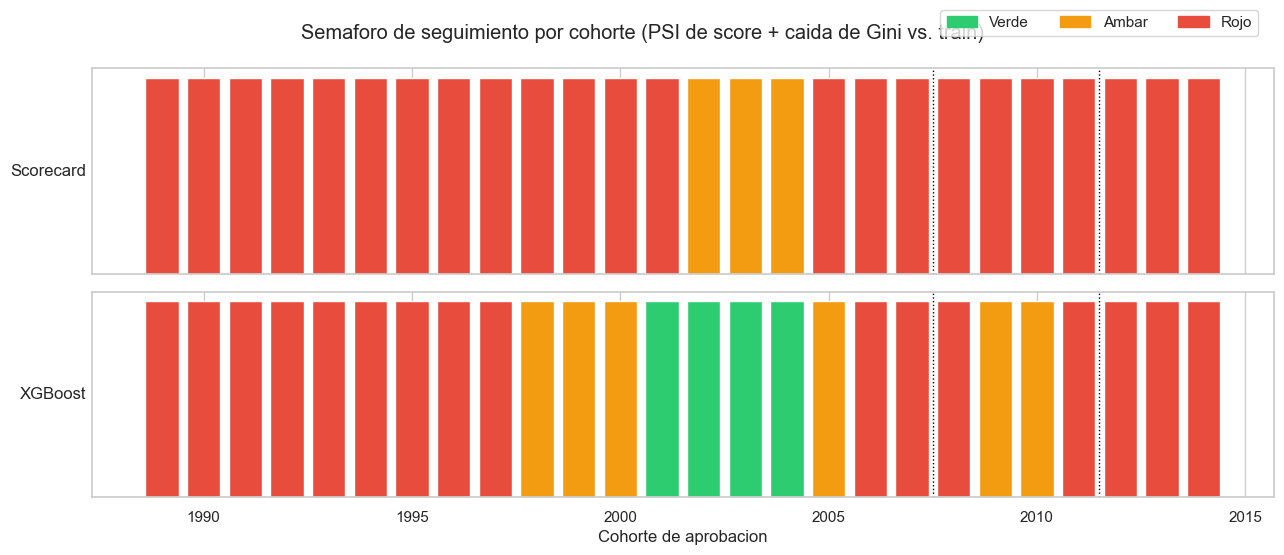

In [19]:
color_map = {"Verde": "#2ecc71", "Ambar": "#f39c12", "Rojo": "#e74c3c", "Sin datos": "#bdc3c7"}

fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
for ax, (model_name, dash) in zip(axes, [("Scorecard", dashboard_sc), ("XGBoost", dashboard_xgb)]):
    colors = [color_map[s] for s in dash["semaforo"]]
    ax.bar(dash.index, [1] * len(dash), color=colors, edgecolor="white")
    ax.set_yticks([])
    ax.set_ylabel(model_name, rotation=0, ha="right", va="center")
    ax.axvline(TRAIN_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)
    ax.axvline(TEST_YEARS[1] + 0.5, color="black", linestyle=":", linewidth=1)

axes[-1].set_xlabel("Cohorte de aprobacion")
fig.suptitle("Semaforo de seguimiento por cohorte (PSI de score + caida de Gini vs. train)")

from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in color_map.items() if l != "Sin datos"]
fig.legend(handles=handles, loc="upper right", ncol=3, bbox_to_anchor=(0.98, 1.02))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "dashboard_semaforo.png", dpi=150)
plt.show()


In [20]:
print("Cohortes en Rojo (accion recomendada: recalibracion/reentrenamiento) por modelo:")
for model_name, dash in [("Scorecard", dashboard_sc), ("XGBoost", dashboard_xgb)]:
    rojas = dash[dash["semaforo"] == "Rojo"].index.tolist()
    print(f"  {model_name}: {rojas}")


Cohortes en Rojo (accion recomendada: recalibracion/reentrenamiento) por modelo:
  Scorecard: [1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
  XGBoost: [1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 2006, 2007, 2008, 2011, 2012, 2013, 2014]


## 7. Conclusiones

- **El pipeline de features "congelado" en la Fase 2 se reprodujo con
  exactitud** (Gini de test identico a la cuarta cifra decimal), lo que
  da confianza en que las metricas de seguimiento de este notebook
  puntuan las cohortes nuevas exactamente como lo haria el modelo en
  produccion, sin fugas ni inconsistencias de preprocesado.
- **El PSI de score y de variables clave es alto incluso dentro del
  propio train** (hasta 0.5+ en algunos anos): es la consecuencia
  esperada de haber entrenado sobre 19 anos que incluyen varios ciclos
  economicos completos, no un fallo del calculo. Por eso el semaforo por
  cohorte se interpreta mejor en relacion a ese "ruido de fondo" que de
  forma literal contra los umbrales 0.10/0.25 aislados.
- **2008-2011 (test, cohortes maduras)** es donde se puede medir
  degradacion genuina, y confirma el hallazgo de la Fase 2 con mas datos:
  el **scorecard pierde mas Gini relativo que XGBoost** en cada cohorte de
  crisis, y la brecha entre ambos modelos se ensancha justo en el pico
  (2006-2008).
- **2012-2014 esta contaminado por censura por la derecha**: la tasa de
  impago observada cae hacia 0 no porque el riesgo real haya bajado, sino
  porque a esos prestamos aun no les ha dado tiempo de hacer default.
  Tanto el Gini como la calibracion en estas cohortes deben leerse con
  esa salvedad -- un "gap" de calibracion negativo grande en 2012-2014 es
  la firma esperada de la censura, no una alarma real.
- **Ninguna variable individual dispara una alerta aislada e
  inexplicable**: los desplazamientos de PSI en `sba_guarantee_pct`
  (politica SBA/ARRA), `Bank_grouped`/`BankState` (consolidacion bancaria
  post-crisis) y `Term` tienen una explicacion de negocio coherente con
  el ciclo economico, lo que refuerza que se trata de un problema de
  **estabilidad del modelo frente a un entorno cambiante**, no de
  **calidad de datos**.
- **Recomendacion operativa**: mantener el scorecard como modelo campeon
  (por interpretabilidad/auditabilidad, segun la Fase 2) pero **acortar
  su ciclo de revalidacion en periodos de inflexion del ciclo economico**,
  ya que es el modelo que mas rapido pierde poder discriminante cuando
  cambia el regimen; usar XGBoost como referencia de "cuanto Gini se esta
  perdiendo" en cada ciclo de seguimiento. El detalle de umbrales y
  acciones recomendadas por nivel de alerta se recoge en
  `reports/informe_seguimiento.md`.
